# Wearable Activity, HbA1c and Sampling Bias in NHANES 2013–2014

This analysis examines whether daily physical activity, measured by wrist-worn accelerometers, is associated with HbA1c in U.S. adults, and how estimates change when a sample does not represent the wider population, a growing concern as health data increasingly come from consumer wearables that are unevenly owned.

**Data:** NHANES 2013–2014 (CDC): accelerometer day summaries (PAXDAY_H), demographics and survey weights (DEMO_H), and HbA1c (GHB_H). NHANES collected wrist-worn accelerometry only in the 2011–2012 and 2013–2014 cycles; 2013–2014 is the more recent of the two and links device data with laboratory measures and survey weights.

**Contents:** 1. Data preparation · 2. Participant summary · 3. Activity and HbA1c · 4. Survey-weighted estimates · 5. Repeated measures within participants · 6. Sampling bias and correction · 7. Monte Carlo simulation of device-owner samples · 8. Sensitivity analysis · Findings and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

activity = pd.read_sas("PAXDAY_H.XPT")   # daily wrist-accelerometer summaries
demo = pd.read_sas("DEMO_H.XPT")         # demographics and survey weights
hba1c = pd.read_sas("GHB_H.XPT")         # HbA1c (glycohemoglobin)

print("Activity:", activity.shape)
print("Demographics:", demo.shape)
print("HbA1c:", hba1c.shape)

Activity: (69018, 15)
Demographics: (10175, 47)
HbA1c: (6979, 2)


## 1. Data preparation
A day was considered valid if the device recorded 24 hours of data with at least 10 hours of waking wear, which also excludes the partial first and last days. Participants were included if they had at least four valid days, so that average activity reflects usual behaviour, and if they were aged 20 or over with an HbA1c result.

Activity is measured in MIMS (Monitor-Independent Movement Summary), a device-independent summary of movement used by NHANES, summed over each day.

In [2]:
# Activity variables
act = activity[["SEQN", "PAXDAYD", "PAXDAYWD", "PAXTMD",
                "PAXMTSD", "PAXWWMD", "PAXSWMD"]].copy()

# Valid days: 24 hours recorded, at least 10 hours of waking wear
act = act[(act["PAXTMD"] == 1440) & (act["PAXWWMD"] >= 600)]

# Link to demographics and HbA1c by participant ID
demo_keep = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "INDFMPIR",
                  "WTMEC2YR", "SDMVPSU", "SDMVSTRA"]]
df = act.merge(demo_keep, on="SEQN").merge(hba1c, on="SEQN")

# Adults aged 20+ with an HbA1c result
df = df[df["RIDAGEYR"] >= 20].dropna(subset=["LBXGH"]).copy()

# Day variables are stored as text; convert to numbers
df["PAXDAYD"] = df["PAXDAYD"].str.decode("utf-8").astype(int)
df["PAXDAYWD"] = df["PAXDAYWD"].str.decode("utf-8").astype(int)
df["weekend"] = df["PAXDAYWD"].isin([1, 7]).astype(int)   # 1 = Sunday, 7 = Saturday

# At least four valid days per participant
valid_days = df.groupby("SEQN")["PAXDAYD"].transform("count")
df = df[valid_days >= 4].copy()

# Analysis units and sex indicator
df["mims_k"] = df["PAXMTSD"] / 1000          # thousands of MIMS
df["sleep_hrs"] = df["PAXSWMD"] / 60         # sleep-wear hours
df["female"] = (df["RIAGENDR"] == 2).astype(int)

print("Valid person-days:", len(df))
print("Participants:", df["SEQN"].nunique())

Valid person-days: 27764
Participants: 4214


## 2. Participant summary
Each participant's valid days are averaged into a single record to describe the analytic sample before modelling.

In [3]:
person = df.groupby("SEQN").agg(
    mims_k=("mims_k", "mean"),
    sleep_hrs=("sleep_hrs", "mean"),
    age=("RIDAGEYR", "first"),
    sex=("RIAGENDR", "first"),
    female=("female", "first"),
    pir=("INDFMPIR", "first"),
    weight=("WTMEC2YR", "first"),
    psu=("SDMVPSU", "first"),
    strata=("SDMVSTRA", "first"),
    hba1c=("LBXGH", "first"),
).reset_index()

print("Participants:", len(person))
person[["mims_k", "sleep_hrs", "age", "female", "pir", "hba1c"]].describe().round(2)

Participants: 4214


,mims_k,sleep_hrs,age,female,pir,hba1c
count,4214.00,4214.00,4214.00,4214.00,3916.00,4214.00
mean,13.49,7.29,49.96,0.53,2.52,5.76
std,3.78,1.78,17.24,0.50,1.64,1.09
min,3.72,0.00,20.00,0.00,0.00,3.50
25%,10.81,6.44,36.00,0.00,1.06,5.20
50%,13.23,7.36,50.00,1.00,2.14,5.50
75%,15.97,8.33,64.00,1.00,4.07,5.90
max,33.30,12.11,80.00,1.00,5.00,17.50


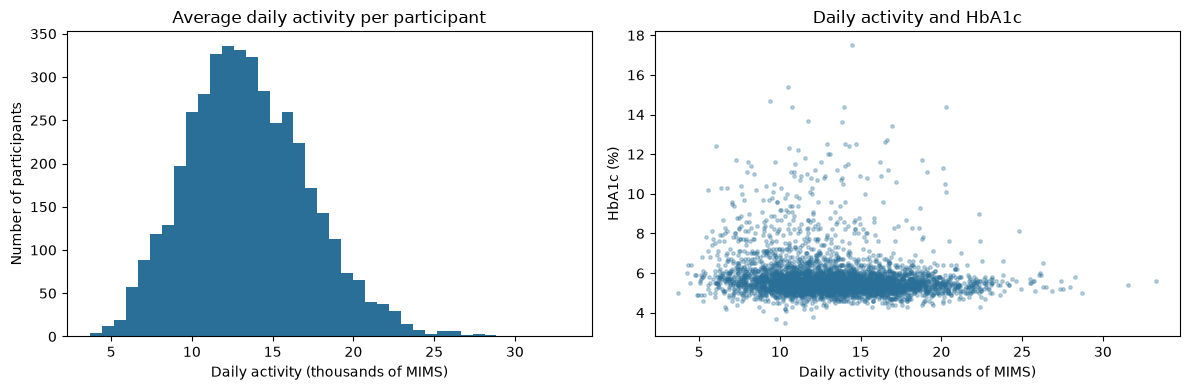

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(person["mims_k"], bins=40, color="#2a6f97")
axes[0].set_title("Average daily activity per participant")
axes[0].set_xlabel("Daily activity (thousands of MIMS)")
axes[0].set_ylabel("Number of participants")

axes[1].scatter(person["mims_k"], person["hba1c"], s=6, alpha=0.3, color="#2a6f97")
axes[1].set_title("Daily activity and HbA1c")
axes[1].set_xlabel("Daily activity (thousands of MIMS)")
axes[1].set_ylabel("HbA1c (%)")

plt.tight_layout()
plt.savefig("fig1_activity_hba1c.png", dpi=150)
plt.show()

## 3. Activity and HbA1c
Age is a likely confounder: older adults tend to be less active and to have higher HbA1c. I therefore compare a model with activity alone against one adjusted for age and sex. Robust (HC3) standard errors are used because HbA1c is right-skewed.

In [5]:
m1 = smf.ols("hba1c ~ mims_k", data=person).fit(cov_type="HC3")
m2 = smf.ols("hba1c ~ mims_k + age + female", data=person).fit(cov_type="HC3")

print("MODEL 1: Activity only")
print(m1.summary().tables[1])
print("\nMODEL 2: Adjusted for age and sex")
print(m2.summary().tables[1])
print("\nR-squared  Model 1:", round(m1.rsquared, 3), "  Model 2:", round(m2.rsquared, 3))

MODEL 1: Activity only
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.3549      0.064     99.805      0.000       6.230       6.480
mims_k        -0.0443      0.004    -10.437      0.000      -0.053      -0.036

MODEL 2: Adjusted for age and sex
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1375      0.085     60.262      0.000       4.970       5.305
mims_k        -0.0151      0.004     -3.470      0.001      -0.024      -0.007
age            0.0172      0.001     21.467      0.000       0.016       0.019
female        -0.0664      0.032     -2.077      0.038      -0.129      -0.004

R-squared  Model 1: 0.024   Model 2: 0.088


## 4. Survey-weighted estimates
NHANES oversamples certain groups by design, and the CDC recommends applying survey weights to activity monitor data. I re-estimate the adjusted model using examination weights, with standard errors clustered by stratum and primary sampling unit to approximate the survey design.

In [6]:
person["cluster"] = person["strata"] * 10 + person["psu"]

m2w = smf.wls("hba1c ~ mims_k + age + female", data=person,
              weights=person["weight"]).fit(cov_type="cluster",
              cov_kwds={"groups": person["cluster"]})

print("MODEL 2 (survey-weighted): Adjusted for age and sex")
print(m2w.summary().tables[1])

MODEL 2 (survey-weighted): Adjusted for age and sex
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1706      0.098     52.706      0.000       4.978       5.363
mims_k        -0.0198      0.005     -3.795      0.000      -0.030      -0.010
age            0.0160      0.001     23.320      0.000       0.015       0.017
female        -0.0807      0.032     -2.535      0.011      -0.143      -0.018


In [7]:
# Summary of the activity coefficient across models
models = {"Unadjusted": m1, "Adjusted (age, sex)": m2, "Adjusted, survey-weighted": m2w}
summary = pd.DataFrame({
    name: {
        "Activity coefficient (per 1,000 MIMS)": m.params["mims_k"],
        "95% CI lower": m.conf_int().loc["mims_k", 0],
        "95% CI upper": m.conf_int().loc["mims_k", 1],
        "p-value": m.pvalues["mims_k"],
    } for name, m in models.items()
}).T.round(4)
summary["p-value"] = summary["p-value"].map(lambda v: "<0.001" if v < 0.001 else f"{v:.3f}")

summary

,"Activity coefficient (per 1,000 MIMS)",95% CI lower,95% CI upper,p-value
Unadjusted,-0.0443,-0.0527,-0.0360,<0.001
"Adjusted (age, sex)",-0.0151,-0.0236,-0.0066,<0.001
"Adjusted, survey-weighted",-0.0198,-0.0300,-0.0096,<0.001


## 5. Repeated measures within participants
Participants contribute multiple days, which are not independent. A mixed-effects model with a random intercept for each participant accounts for this clustering. I also estimate the intraclass correlation (ICC): the proportion of variation in daily activity attributable to differences between people rather than from day to day.

In [8]:
mm = smf.mixedlm(
    "mims_k ~ LBXGH + weekend + RIDAGEYR + female",
    data=df,
    groups=df["SEQN"]
).fit()

print(mm.summary())

var_between = mm.cov_re.iloc[0, 0]
var_within = mm.scale
print("\nICC:", round(var_between / (var_between + var_within), 2))

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mims_k     
No. Observations: 27764   Method:             REML       
No. Groups:       4214    Scale:              6.5286     
Min. group size:  4       Log-Likelihood:     -70728.0181
Max. group size:  7       Converged:          Yes        
Mean group size:  6.6                                    
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     18.077    0.307  58.925 0.000 17.476 18.679
LBXGH         -0.169    0.052  -3.279 0.001 -0.270 -0.068
weekend       -0.649    0.035 -18.798 0.000 -0.717 -0.582
RIDAGEYR      -0.076    0.003 -23.377 0.000 -0.083 -0.070
female         0.735    0.108   6.803 0.000  0.523  0.947
Group Var     11.224    0.113                            


ICC: 0.63


## 6. Sampling bias and correction
Ownership of consumer wearables varies by income, so device-derived data may under-represent groups at higher risk of chronic disease. This section examines that problem in a simplified form.

Diabetes is defined as HbA1c ≥ 6.5%. I first compare survey-weighted and unweighted estimates in the analytic sample. In Section 7, I then simulate "device-owner" samples in which inclusion depends on income (assumed probabilities: 20% low, 50% middle, 80% high income), and assess whether inverse probability weighting (IPW) corrects the resulting bias.

In [9]:
p = person.dropna(subset=["pir"]).copy()
p["diabetes"] = (p["hba1c"] >= 6.5).astype(int)
p["income_grp"] = pd.cut(p["pir"], [-0.1, 1, 3, 5.1], labels=["low", "middle", "high"])

def wmean(x, w):
    return np.sum(x * w) / np.sum(w)

pop_act = wmean(p["mims_k"], p["weight"])
pop_dm = wmean(p["diabetes"], p["weight"])

results = pd.DataFrame({
    "Survey-weighted": [pop_act, pop_dm * 100],
    "Unweighted": [p["mims_k"].mean(), p["diabetes"].mean() * 100],
}, index=["Mean daily activity (k MIMS)", "HbA1c-defined diabetes ≥6.5% (%)"]).round(2)

print("Participants with income data:", len(p), "of", len(person))
results

Participants with income data: 3916 of 4214


,Survey-weighted,Unweighted
Mean daily activity (k MIMS),13.43,13.40
HbA1c-defined diabetes ≥6.5% (%),9.24,11.44


## 7. Monte Carlo simulation of device-owner samples
A single simulated sample is subject to random variation, so device ownership is simulated 500 times. For each sample, diabetes prevalence is estimated with survey weights alone (which cannot account for selection by device ownership) and with IPW (survey weight divided by the probability of owning a device).

In [10]:
rows = []
for grp, g in p.groupby("income_grp", observed=True):
    rows.append({
        "income_group": grp,
        "share_of_population_%": round(g["weight"].sum() / p["weight"].sum() * 100, 1),
        "diabetes_%": round(wmean(g["diabetes"], g["weight"]) * 100, 2),
        "activity_k_MIMS": round(wmean(g["mims_k"], g["weight"]), 2),
    })
inc = pd.DataFrame(rows)
print(inc.to_string(index=False))

rng = np.random.default_rng(42)
probs = p["income_grp"].map({"low": 0.2, "middle": 0.5, "high": 0.8}).astype(float).values
sw_list, ipw_list = [], []
for i in range(500):
    keep = rng.random(len(p)) < probs
    d, pr = p[keep], probs[keep]
    sw_list.append(wmean(d["diabetes"], d["weight"]) * 100)
    ipw_list.append(wmean(d["diabetes"], d["weight"] / pr) * 100)

print("\nHbA1c-defined diabetes, analytic sample (survey-weighted):", round(pop_dm * 100, 2), "%")
print("Simulated device owners, survey-weighted (average of 500):", round(np.mean(sw_list), 2), "%")
print("Simulated device owners, IPW-corrected (average of 500):", round(np.mean(ipw_list), 2), "%")
print("Spread of IPW estimates (SD):", round(np.std(ipw_list), 2))

income_group  share_of_population_%  diabetes_%  activity_k_MIMS
         low                   15.3       10.52            13.89
      middle                   36.3        9.68            13.58
        high                   48.3        8.50            13.17

HbA1c-defined diabetes, analytic sample (survey-weighted): 9.24 %
Simulated device owners, survey-weighted (average of 500): 8.94 %
Simulated device owners, IPW-corrected (average of 500): 9.21 %
Spread of IPW estimates (SD): 0.51


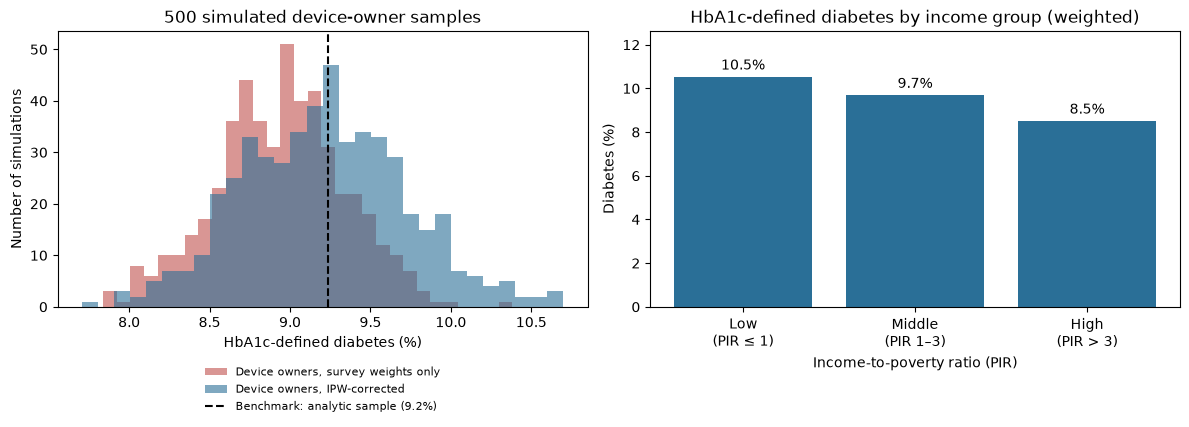

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: distribution of 500 simulated estimates
axes[0].hist(sw_list, bins=30, alpha=0.6, color="#c0504d",
             label="Device owners, survey weights only")
axes[0].hist(ipw_list, bins=30, alpha=0.6, color="#2a6f97",
             label="Device owners, IPW-corrected")
axes[0].axvline(pop_dm * 100, color="black", linestyle="--",
                label=f"Benchmark: analytic sample ({pop_dm * 100:.1f}%)")
axes[0].set_title("500 simulated device-owner samples")
axes[0].set_xlabel("HbA1c-defined diabetes (%)")
axes[0].set_ylabel("Number of simulations")
axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1, frameon=False)

# Right: the income gradient that drives the bias
labels = ["Low\n(PIR ≤ 1)", "Middle\n(PIR 1–3)", "High\n(PIR > 3)"]
bars = axes[1].bar(labels, inc["diabetes_%"], color="#2a6f97")
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].set_title("HbA1c-defined diabetes by income group (weighted)")
axes[1].set_xlabel("Income-to-poverty ratio (PIR)")
axes[1].set_ylabel("Diabetes (%)")
axes[1].set_ylim(0, max(inc["diabetes_%"]) * 1.2)

plt.tight_layout()
plt.savefig("fig2_sampling_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Sensitivity analysis
To test whether the main result depends on the four-day inclusion rule, I re-estimate the adjusted regression using a minimum of three valid days.

In [12]:
# Rebuild the adult sample before the minimum-days rule
base = act.merge(demo_keep, on="SEQN").merge(hba1c, on="SEQN")
base = base[base["RIDAGEYR"] >= 20].dropna(subset=["LBXGH"]).copy()
base_days = base.groupby("SEQN")["PAXDAYD"].transform("count")

for min_days in [3, 4]:
    sub = base[base_days >= min_days]
    per = sub.groupby("SEQN").agg(
        mims=("PAXMTSD", "mean"),
        age=("RIDAGEYR", "first"),
        sex=("RIAGENDR", "first"),
        hba1c=("LBXGH", "first"),
    ).reset_index()
    per["mims_k"] = per["mims"] / 1000
    per["female"] = (per["sex"] == 2).astype(int)
    fit = smf.ols("hba1c ~ mims_k + age + female", data=per).fit(cov_type="HC3")
    ci = fit.conf_int().loc["mims_k"]
    print(f"Minimum {min_days} valid days: n = {len(per)}, "
          f"activity coefficient = {fit.params['mims_k']:.4f} "
          f"(95% CI {ci[0]:.4f} to {ci[1]:.4f}), p {'< 0.001' if fit.pvalues['mims_k'] < 0.001 else '= ' + str(round(fit.pvalues['mims_k'], 3))}")

Minimum 3 valid days: n = 4315, activity coefficient = -0.0148 (95% CI -0.0230 to -0.0065), p < 0.001
Minimum 4 valid days: n = 4214, activity coefficient = -0.0151 (95% CI -0.0236 to -0.0066), p < 0.001


## Findings
- Higher daily activity was associated with lower HbA1c. Adjusting for age and sex reduced the estimate by about two-thirds (from −0.044 to −0.015 per 1,000 MIMS), illustrating confounding by age. The association persisted in the survey-weighted model (−0.020; 95% CI −0.030 to −0.010).
- The association is modest: a difference of about 5,000 MIMS per day (roughly the interquartile range of activity) corresponds to an HbA1c about 0.08–0.10 percentage points lower.
- In the mixed-effects model, participants with higher HbA1c had lower average daily activity, and daily activity was about 5% lower on weekend days. The ICC of 0.63 indicates that most variation in daily activity lies between people, although over a third occurs within people from day to day.
- Ignoring survey weights overstated HbA1c-defined diabetes (11.4% unweighted vs 9.2% weighted).
- Across 500 simulated device-owner samples skewed toward higher incomes, survey weights alone underestimated diabetes on average (8.9% vs 9.2%), because higher-risk groups were under-represented. IPW recovered the benchmark on average (9.2%), although individual estimates varied (SD 0.5 percentage points).
- The association was robust to the inclusion rule: requiring three rather than four valid days gave a nearly identical estimate (−0.0148 vs −0.0151 per 1,000 MIMS).

## Observations
Lower-income participants recorded slightly higher wrist-measured activity than higher-income participants, possibly reflecting more physically demanding work. In this sample, the bias from selective device ownership therefore reflected under-representation of people with more disease rather than of less active people.

## Future directions
- Replicate the analysis in another national survey with device-measured activity, such as the Canadian Health Measures Survey.
- Adjust for BMI and diabetes medication.
- Extend the analysis to sleep patterns.

## Limitations
- Cross-sectional data: associations do not imply causation, and illness may reduce activity rather than the reverse.
- Diabetes is defined only by HbA1c ≥ 6.5%, excluding people whose diabetes is controlled by medication; BMI and medication are not adjusted for.
- The mixed-effects model is unweighted, and the weighted regression approximates the full survey design.
- The analytic sample was not re-weighted for missing device or laboratory data, and participants without income data were excluded from the bias analysis.
- Device ownership was simulated using assumed probabilities; IPW worked here because the true probabilities were known, which is rarely the case in practice.
- Days with quality-control flags were not excluded, and age is top-coded at 80.